# Monthly Modeling Pipeline
Load engineered NOAA climate features, evaluate regression and classification models, and record a light-weight forecasting workflow.

## Data loading

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_PATH = Path("../data/monthly_data.csv")

monthly = (
    pd.read_csv(DATA_PATH, parse_dates=['ym'])
    .sort_values(['STATION', 'year', 'month'])
    .reset_index(drop=True)
)

TRAIN_THRESHOLD = 2021
REL_EXTREME_Q = 0.90

print(f"Monthly rows: {len(monthly):,}, stations: {monthly['STATION'].nunique()}")
monthly.head()


Monthly rows: 2,400, stations: 7


,STATION,year,month,PRCP_sum,TMAX_mean,TMIN_mean,TMEAN,ym
0,USW00003017,1996,6,1.74,85.083333,53.291667,69.187500,1996-06-01
1,USW00003017,1996,7,1.01,87.967742,58.774194,73.370968,1996-07-01
2,USW00003017,1996,8,0.56,87.064516,56.129032,71.596774,1996-08-01
3,USW00003017,1996,9,2.34,74.600000,46.900000,60.750000,1996-09-01
4,USW00003017,1996,10,0.39,64.903226,36.774194,50.838710,1996-10-01


## Feature engineering

In [4]:
HEAT_THRESHOLD_C = 32.0  # ~90F
COLD_THRESHOLD_C = 0.0   # freezing point


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['STATION', 'year', 'month']).copy()
    df['month'] = df['month'].astype(int)

    # Daily spread and rolling precipitation signals
    df['temp_range'] = df['TMAX_mean'] - df['TMIN_mean']
    df['prcp_roll3_mean'] = (
        df.groupby('STATION')['PRCP_sum']
        .transform(lambda s: s.rolling(window=3, min_periods=1).mean())
    )
    df['prcp_roll6_mean'] = (
        df.groupby('STATION')['PRCP_sum']
        .transform(lambda s: s.rolling(window=6, min_periods=1).mean())
    )

    # Rolling behavior for temperature
    df['tmean_roll3_mean'] = (
        df.groupby('STATION')['TMEAN']
        .transform(lambda s: s.rolling(window=3, min_periods=2).mean())
    )
    df['tmean_roll6_std'] = (
        df.groupby('STATION')['TMEAN']
        .transform(lambda s: s.rolling(window=6, min_periods=2).std())
    )

    # Cyclical encoding for the month feature
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

    # Temperature/precipitation lags
    for lag in (1, 3, 6, 12):
        df[f'TMEAN_lag{lag}'] = df.groupby('STATION')['TMEAN'].shift(lag)
    for lag in (1, 3, 12):
        df[f'PRCP_lag{lag}'] = df.groupby('STATION')['PRCP_sum'].shift(lag)

    df['TMEAN_roll3'] = (
        df.groupby('STATION')['TMEAN']
        .transform(lambda s: s.rolling(window=3, min_periods=2).mean())
    )
    df['TMEAN_roll6'] = (
        df.groupby('STATION')['TMEAN']
        .transform(lambda s: s.rolling(window=6, min_periods=3).mean())
    )

    df['heat_extreme'] = (df['TMAX_mean'] >= HEAT_THRESHOLD_C).astype(int)
    df['cold_extreme'] = (df['TMIN_mean'] <= COLD_THRESHOLD_C).astype(int)

    monthly_station_mean = (
        df.groupby(['STATION', 'month'])['PRCP_sum'].transform('mean')
    )
    df['PRCP_anom'] = df['PRCP_sum'] - monthly_station_mean
    df['PRCP_to_month_mean'] = df['PRCP_sum'] / (monthly_station_mean + 1e-3)

    df['TMEAN_station_norm'] = (
        df['TMEAN'] - df.groupby('STATION')['TMEAN'].transform('mean')
    )
    df['PRCP_station_norm'] = (
        df['PRCP_sum'] - df.groupby('STATION')['PRCP_sum'].transform('mean')
    )
    df['PRCP_log'] = np.log1p(df['PRCP_sum'].clip(lower=0))

    return df


In [6]:
monthly_fe = add_engineered_features(monthly)


def fill_station_missing(df: pd.DataFrame) -> pd.DataFrame:
    """Forward fill within each station to avoid leaking future information."""
    return (
        df.groupby('STATION', group_keys=False)
        .apply(lambda grp: grp.ffill())
    )

monthly_fe = fill_station_missing(monthly_fe)
monthly_fe = monthly_fe.dropna(subset=['TMEAN', 'PRCP_sum']).reset_index(drop=True)

# Relative extreme heat label (train years only, station/month 90th percentile)
train_mask_rel = monthly_fe['year'] < TRAIN_THRESHOLD
station_month_quantiles = (
    monthly_fe[train_mask_rel]
    .groupby(['STATION', 'month'])['TMEAN']
    .quantile(REL_EXTREME_Q)
)
monthly_fe = monthly_fe.merge(
    station_month_quantiles.rename('tmean_quantile'),
    on=['STATION', 'month'],
    how='left'
)
monthly_fe['heat_extreme_rel'] = (
    monthly_fe['TMEAN'] >= monthly_fe['tmean_quantile']
).astype(int)
monthly_fe['heat_extreme_next_rel'] = (
    monthly_fe.groupby('STATION')['heat_extreme_rel'].shift(-1)
)
monthly_fe = monthly_fe.drop(columns=['tmean_quantile'])

monthly_fe['TMEAN_next'] = monthly_fe.groupby('STATION')['TMEAN'].shift(-1)
monthly_fe['TMAX_next'] = monthly_fe.groupby('STATION')['TMAX_mean'].shift(-1)
monthly_fe['TMIN_next'] = monthly_fe.groupby('STATION')['TMIN_mean'].shift(-1)
monthly_fe['PRCP_next'] = monthly_fe.groupby('STATION')['PRCP_sum'].shift(-1)

print(f'Feature engineered rows: {len(monthly_fe):,}')
monthly_fe.head()


Feature engineered rows: 2,400


/var/folders/x8/59lsc6h95bz9br5gwthbx0rw0000gn/T/ipykernel_54923/221946923.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: grp.ffill())


,STATION,year,month,PRCP_sum,TMAX_mean,TMIN_mean,TMEAN,ym,temp_range,prcp_roll3_mean,...,PRCP_to_month_mean,TMEAN_station_norm,PRCP_station_norm,PRCP_log,heat_extreme_rel,heat_extreme_next_rel,TMEAN_next,TMAX_next,TMIN_next,PRCP_next
0,USW00003017,1996,6,1.74,85.083333,53.291667,69.187500,1996-06-01,31.791667,1.740000,...,0.995875,18.051212,0.606257,1.007958,0,0.0,73.370968,87.967742,58.774194,1.01
1,USW00003017,1996,7,1.01,87.967742,58.774194,73.370968,1996-07-01,29.193548,1.375000,...,0.524356,22.234680,-0.123743,0.698135,0,0.0,71.596774,87.064516,56.129032,0.56
2,USW00003017,1996,8,0.56,87.064516,56.129032,71.596774,1996-08-01,30.935484,1.103333,...,0.400306,20.460486,-0.573743,0.444686,0,0.0,60.750000,74.600000,46.900000,2.34
3,USW00003017,1996,9,2.34,74.600000,46.900000,60.750000,1996-09-01,27.700000,1.303333,...,2.595128,9.613712,1.206257,1.205971,0,0.0,50.838710,64.903226,36.774194,0.39
4,USW00003017,1996,10,0.39,64.903226,36.774194,50.838710,1996-10-01,28.129032,1.096667,...,0.432852,-0.297578,-0.743743,0.329304,0,0.0,37.183333,50.966667,23.400000,0.38


## Modeling dataframe

In [7]:
feature_cols = [
    'PRCP_sum', 'TMAX_mean', 'TMIN_mean', 'TMEAN',
    'temp_range', 'prcp_roll3_mean', 'prcp_roll6_mean', 'tmean_roll3_mean', 'tmean_roll6_std',
    'month_sin', 'month_cos',
    'TMEAN_lag1', 'TMEAN_lag3', 'TMEAN_lag6', 'TMEAN_lag12',
    'PRCP_lag1', 'PRCP_lag3', 'PRCP_lag12',
    'TMEAN_roll3', 'TMEAN_roll6',
    'heat_extreme', 'cold_extreme', 'PRCP_anom', 'PRCP_to_month_mean',
    'TMEAN_station_norm', 'PRCP_station_norm', 'PRCP_log'
]

reg_targets = ['TMEAN_next', 'TMAX_next', 'TMIN_next', 'PRCP_next']
clf_target = 'heat_extreme_next_rel'

model_df = monthly_fe.dropna(subset=feature_cols + reg_targets + [clf_target]).reset_index(drop=True)
summer_mask = model_df['month'].between(5, 9)

print('Modeling dataframe shape:', model_df.shape)
print('Relative extreme heat class balance (all months):')
print(model_df[clf_target].value_counts().rename('samples'))
print('Relative extreme heat class balance (May-Sep only):')
print(model_df.loc[summer_mask, clf_target].value_counts().rename('samples'))


Modeling dataframe shape: (2309, 37)
Relative extreme heat class balance (all months):
heat_extreme_next_rel
0.0    1989
1.0     320
Name: samples, dtype: int64
Relative extreme heat class balance (May-Sep only):
heat_extreme_next_rel
0.0    829
1.0    144
Name: samples, dtype: int64


## Train/test split and scaling

In [8]:
from sklearn.preprocessing import StandardScaler

def _log1p_prcp(series: pd.Series) -> pd.Series:
    return np.log1p(series.clip(lower=0))

def _inv_log1p_prcp(values: pd.Series) -> pd.Series:
    return np.expm1(values)

train_threshold = TRAIN_THRESHOLD  # train < 2021, test >= 2021
train_mask = model_df['year'] < train_threshold
test_mask = ~train_mask

X = model_df[feature_cols]
y_reg = model_df[reg_targets]

X_train, X_test = X[train_mask], X[test_mask]
y_reg_train, y_reg_test = y_reg[train_mask], y_reg[test_mask]

y_reg_train_transformed = y_reg_train.copy()
y_reg_train_transformed['PRCP_next'] = _log1p_prcp(y_reg_train_transformed['PRCP_next'])

y_reg_test_transformed = y_reg_test.copy()
y_reg_test_transformed['PRCP_next'] = _log1p_prcp(y_reg_test_transformed['PRCP_next'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Classification subset: May-Sep only
clf_df = model_df[model_df['month'].between(5, 9)].copy()
clf_train_mask = clf_df['year'] < train_threshold
clf_test_mask = ~clf_train_mask

X_clf = clf_df[feature_cols]
y_clf = clf_df[clf_target].astype(int)

clf_scaler = StandardScaler()
X_clf_train_scaled = clf_scaler.fit_transform(X_clf[clf_train_mask])
X_clf_test_scaled = clf_scaler.transform(X_clf[clf_test_mask])
y_clf_train = y_clf[clf_train_mask]
y_clf_test = y_clf[clf_test_mask]

print('Regression samples - train/test:', X_train.shape[0], X_test.shape[0])
print('Classification samples (May-Sep) - train/test:', X_clf_train_scaled.shape[0], X_clf_test_scaled.shape[0])
print('Classification class counts (train):', y_clf_train.value_counts().to_dict())
print('Classification class counts (test):', y_clf_test.value_counts().to_dict())


Regression samples - train/test: 1980 329
Classification samples (May-Sep) - train/test: 833 140
Classification class counts (train): {0: 726, 1: 107}
Classification class counts (test): {0: 103, 1: 37}


## Regression models

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

PRCP_TARGET = 'PRCP_next'

def _convert_predictions(pred_array):
    pred_df = pd.DataFrame(pred_array, columns=reg_targets)
    pred_df[PRCP_TARGET] = _inv_log1p_prcp(pred_df[PRCP_TARGET]).clip(lower=0)
    return pred_df


def summarize_regression(model, name):
    model.fit(X_train_scaled, y_reg_train_transformed)
    preds_df = _convert_predictions(model.predict(X_test_scaled))
    for col in reg_targets:
        rmse = mean_squared_error(y_reg_test[col], preds_df[col]) ** 0.5
        mae = mean_absolute_error(y_reg_test[col], preds_df[col])
        r2 = r2_score(y_reg_test[col], preds_df[col])
        print(f"{name} - {col}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")
    print()
    return preds_df.values, model

reg_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=1),
    'Gradient Boosting Regressor': MultiOutputRegressor(GradientBoostingRegressor(random_state=42))
}

reg_predictions = {}
fitted_models = {}
for model_name, estimator in reg_models.items():
    preds, fitted = summarize_regression(estimator, model_name)
    reg_predictions[model_name] = preds
    fitted_models[model_name] = fitted

y_reg_pred_lr = reg_predictions['Linear Regression']
y_reg_pred_rf = reg_predictions['Random Forest Regressor']
y_reg_pred_gb = reg_predictions['Gradient Boosting Regressor']
linreg = fitted_models['Linear Regression']
rf_reg = fitted_models['Random Forest Regressor']
gb_reg = fitted_models['Gradient Boosting Regressor']

rmse_naive = mean_squared_error(y_reg_test['TMEAN_next'], X_test['TMEAN_lag1']) ** 0.5
print(f"Naive baseline RMSE (TMEAN_next via lag1): {rmse_naive:.3f}")


Linear Regression - TMEAN_next: RMSE=3.287, MAE=2.471, R2=0.961
Linear Regression - TMAX_next: RMSE=3.802, MAE=2.888, R2=0.952
Linear Regression - TMIN_next: RMSE=3.335, MAE=2.472, R2=0.961
Linear Regression - PRCP_next: RMSE=2.201, MAE=1.372, R2=0.457

Random Forest Regressor - TMEAN_next: RMSE=3.031, MAE=2.324, R2=0.967
Random Forest Regressor - TMAX_next: RMSE=3.526, MAE=2.737, R2=0.959
Random Forest Regressor - TMIN_next: RMSE=3.023, MAE=2.269, R2=0.968
Random Forest Regressor - PRCP_next: RMSE=2.025, MAE=1.322, R2=0.540

Gradient Boosting Regressor - TMEAN_next: RMSE=3.123, MAE=2.335, R2=0.965
Gradient Boosting Regressor - TMAX_next: RMSE=3.635, MAE=2.769, R2=0.956
Gradient Boosting Regressor - TMIN_next: RMSE=3.160, MAE=2.361, R2=0.965
Gradient Boosting Regressor - PRCP_next: RMSE=2.052, MAE=1.335, R2=0.528

Naive baseline RMSE (TMEAN_next via lag1): 13.327


### Regression metric summary

Heatmap compares RMSE across models and targets so we can quickly spot which estimator performs best for each variable.

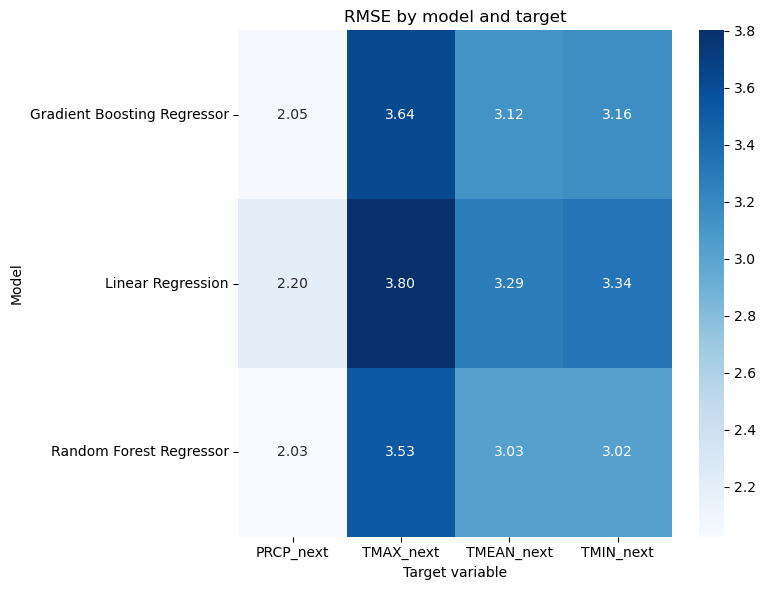

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

metric_records = []

for model_name, preds in reg_predictions.items():
    preds_df = pd.DataFrame(preds, columns=reg_targets)
    for target in reg_targets:
        rmse = mean_squared_error(y_reg_test[target], preds_df[target]) ** 0.5
        metric_records.append({'model': model_name, 'target': target, 'rmse': rmse})
metrics_df = pd.DataFrame(metric_records)
pivot_rmse = metrics_df.pivot(index='model', columns='target', values='rmse')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_rmse, annot=True, fmt='.2f', cmap='Blues')
plt.title('RMSE by model and target')
plt.ylabel('Model')
plt.xlabel('Target variable')
plt.tight_layout()
plt.show()

### One-month-ahead forecast
Use a persistence assumption: the most recent engineered features per station (through month *t*) are kept as the inputs for forecasting month *t+1*, while purely calendar-dependent features (month number, sine/cosine) and the obvious lag-1 values are updated. 

In [13]:
# Use the most recent record per station to forecast the next month
last_rows = monthly_fe.groupby('STATION').tail(1).reset_index(drop=True)
future_df = last_rows.copy()
future_df['month'] = future_df['month'] + 1
rollover = future_df['month'] == 13
future_df.loc[rollover, 'month'] = 1
future_df.loc[rollover, 'year'] += 1
future_df['month_sin'] = np.sin(2 * np.pi * future_df['month'] / 12.0)
future_df['month_cos'] = np.cos(2 * np.pi * future_df['month'] / 12.0)

future_df['TMEAN_lag1'] = last_rows['TMEAN']
future_df['PRCP_lag1'] = last_rows['PRCP_sum']

for col in ['TMEAN_lag3', 'TMEAN_lag6', 'TMEAN_lag12', 'PRCP_lag3', 'PRCP_lag12']:
    if col in future_df.columns:
        future_df[col] = last_rows[col]

persistence_cols = [
    'temp_range', 'prcp_roll3_mean', 'prcp_roll6_mean',
    'tmean_roll3_mean', 'tmean_roll6_std', 'TMEAN_roll3', 'TMEAN_roll6',
    'heat_extreme', 'cold_extreme', 'PRCP_anom', 'PRCP_to_month_mean',
    'TMEAN_station_norm', 'PRCP_station_norm'
]
for col in persistence_cols:
    if col in future_df.columns:
        future_df[col] = last_rows[col]

future_df['PRCP_log'] = np.log1p(future_df['PRCP_sum'].clip(lower=0))

X_future = future_df[feature_cols]
X_future_scaled = scaler.transform(X_future)


def _print_forecast(model, name):
    preds_df = _convert_predictions(model.predict(X_future_scaled))
    print(f'{name} forecast:')
    for col in reg_targets:
        print(f'  {col}: {preds_df.iloc[0][col]:.3f}')
    return preds_df

future_pred_lr = _print_forecast(linreg, 'Linear Regression')
future_pred_rf = _print_forecast(rf_reg, 'Random Forest')
future_pred_gb = _print_forecast(gb_reg, 'Gradient Boosting')


Linear Regression forecast:
  TMEAN_next: 32.817
  TMAX_next: 45.905
  TMIN_next: 19.914
  PRCP_next: 0.510
Random Forest forecast:
  TMEAN_next: 32.022
  TMAX_next: 44.998
  TMIN_next: 19.161
  PRCP_next: 0.407
Gradient Boosting forecast:
  TMEAN_next: 30.163
  TMAX_next: 45.055
  TMIN_next: 17.694
  PRCP_next: 0.400


In [14]:
from sklearn.model_selection import TimeSeriesSplit

# Rolling-origin evaluation for TMEAN_next
tscv = TimeSeriesSplit(n_splits=5)
cv_rmse = []
for split_idx, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    scaler_cv = StandardScaler()
    X_train_cv = scaler_cv.fit_transform(X.iloc[train_idx])
    X_test_cv = scaler_cv.transform(X.iloc[test_idx])
    y_train_cv = y_reg.iloc[train_idx]['TMEAN_next']
    y_test_cv = y_reg.iloc[test_idx]['TMEAN_next']

    gb_cv = GradientBoostingRegressor(random_state=42)
    gb_cv.fit(X_train_cv, y_train_cv)
    preds_cv = gb_cv.predict(X_test_cv)
    rmse_cv = mean_squared_error(y_test_cv, preds_cv) ** 0.5
    cv_rmse.append(rmse_cv)
    print(f'Split {split_idx}: RMSE={rmse_cv:.3f}')

print(f'Rolling CV RMSE avg: {np.mean(cv_rmse):.3f} ± {np.std(cv_rmse):.3f}')


Split 1: RMSE=5.323
Split 2: RMSE=4.446
Split 3: RMSE=3.714
Split 4: RMSE=3.589
Split 5: RMSE=5.041
Rolling CV RMSE avg: 4.423 ± 0.691


### Cross-validation comparison across models

Rolling-origin cross-validation (5 folds) for each regression model focused on `TMEAN_next` provides a fair comparison beyond the holdout set.

In [15]:
from sklearn.base import clone

cv_records = []
for model_name, estimator in reg_models.items():
    for split_idx, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        scaler_cv = StandardScaler()
        X_train_cv = scaler_cv.fit_transform(X.iloc[train_idx])
        X_test_cv = scaler_cv.transform(X.iloc[test_idx])
        y_train_cv = y_reg.iloc[train_idx][['TMEAN_next']]
        y_test_cv = y_reg.iloc[test_idx][['TMEAN_next']]

        model_cv = clone(estimator)
        model_cv.fit(X_train_cv, y_train_cv)
        preds_cv = model_cv.predict(X_test_cv)
        preds_cv = preds_cv.ravel()
        rmse_cv = mean_squared_error(y_test_cv['TMEAN_next'], preds_cv) ** 0.5
        cv_records.append({'model': model_name, 'split': split_idx, 'rmse': rmse_cv})

cv_df = pd.DataFrame(cv_records)
summary = cv_df.groupby('model')['rmse'].agg(['mean', 'std']).sort_values('mean')
print(summary)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

                                 mean       std
model                                          
Gradient Boosting Regressor  4.422579  0.772929
Random Forest Regressor      5.012944  0.706382
Linear Regression            5.099876  2.589556


In [16]:
from sklearn.inspection import permutation_importance

# Permutation importance for Gradient Boosting on TMEAN_next
gb_single = GradientBoostingRegressor(random_state=42)
gb_single.fit(X_train_scaled, y_reg_train['TMEAN_next'])
perm = permutation_importance(
    gb_single,
    X_test_scaled,
    y_reg_test['TMEAN_next'],
    n_repeats=20,
    random_state=42,
    scoring='neg_mean_squared_error'
)

perm_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': perm.importances_mean,
    'std': perm.importances_std
}).sort_values('importance', ascending=False)

perm_df.head(10)


,feature,importance,std
3,TMEAN,119.937750,6.727162
10,month_cos,29.332054,2.217072
14,TMEAN_lag12,26.046935,1.701199
9,month_sin,23.276299,1.631037
1,TMAX_mean,16.593927,1.596225
2,TMIN_mean,8.150551,0.598671
13,TMEAN_lag6,3.331771,0.479883
8,tmean_roll6_std,3.039753,0.374192
12,TMEAN_lag3,2.606752,0.424656
4,temp_range,0.485144,0.113030


### Feature importance visualization

Bar plot of the permutation importance scores highlights which engineered inputs drive the Gradient Boosting model for `TMEAN_next`.

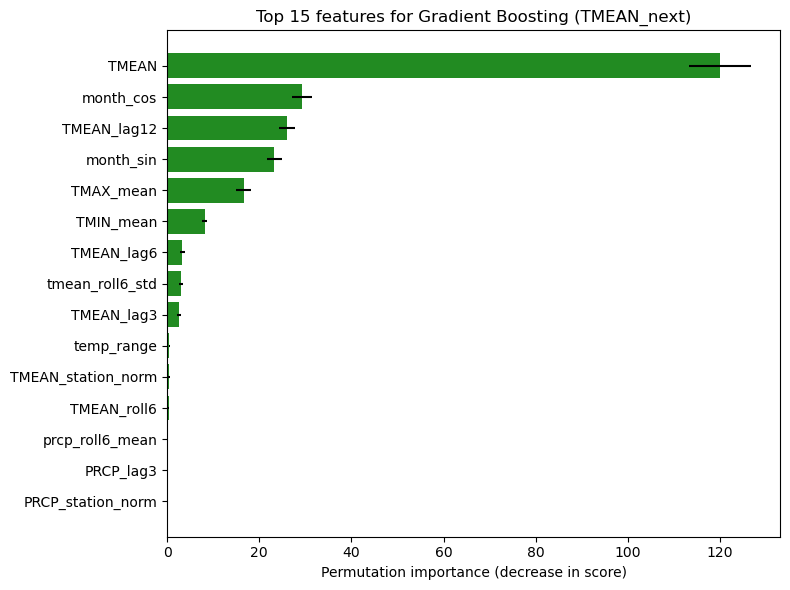

In [17]:
import matplotlib.pyplot as plt
top_features = perm_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_features['feature'], top_features['importance'], xerr=top_features['std'], color='forestgreen')
ax.set_xlabel('Permutation importance (decrease in score)')
ax.set_title('Top 15 features for Gradient Boosting (TMEAN_next)')
plt.tight_layout()
plt.show()

### Gradient Boosting baseline
Gradient boosting regressor before diving into the heat classification so the regression suite now has three distinct perspectives.

In [18]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

gb_tuned = MultiOutputRegressor(
    GradientBoostingRegressor(
        random_state=42, learning_rate=0.05, n_estimators=500, max_depth=3, subsample=0.8
    )
)
gb_preds_tuned, gb_model_tuned = summarize_regression(
    gb_tuned, 'Gradient Boosting Regressor'
)
reg_predictions['Gradient Boosting Regressor'] = gb_preds_tuned
fitted_models['Gradient Boosting Regressor'] = gb_model_tuned


Gradient Boosting Regressor - TMEAN_next: RMSE=3.050, MAE=2.306, R2=0.967
Gradient Boosting Regressor - TMAX_next: RMSE=3.467, MAE=2.647, R2=0.960
Gradient Boosting Regressor - TMIN_next: RMSE=3.033, MAE=2.292, R2=0.967
Gradient Boosting Regressor - PRCP_next: RMSE=2.082, MAE=1.338, R2=0.514



## Classification model (May-Sep relative extreme heat)
Focus on summer months (May–Sep) where the relative label is most meaningful. Logistic Regression with `class_weight="balanced"` is the sole classifier.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

log_clf = LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced')
log_clf.fit(X_clf_train_scaled, y_clf_train)
y_clf_prob = log_clf.predict_proba(X_clf_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_clf_test, y_clf_prob)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_idx = f1_scores[:-1].argmax()
best_threshold = thresholds[best_idx]
print(f'Logistic Regression optimal probability threshold (by F1): {best_threshold:.2f}')

for label, threshold in {
    'Default 0.5 threshold': 0.5,
    'F1-optimized threshold': best_threshold,
}.items():
    preds = (y_clf_prob >= threshold).astype(int)
    print(f"Logistic Regression ({label})")
    print(classification_report(y_clf_test, preds, digits=3, zero_division=0))
    print('Confusion matrix:')
    print(confusion_matrix(y_clf_test, preds))

print(f"Logistic Regression ROC AUC: {roc_auc_score(y_clf_test, y_clf_prob):.3f}")


Logistic Regression optimal probability threshold (by F1): 0.52
Logistic Regression (Default 0.5 threshold)
              precision    recall  f1-score   support

           0      0.838     0.553     0.667       103
           1      0.361     0.703     0.477        37

    accuracy                          0.593       140
   macro avg      0.600     0.628     0.572       140
weighted avg      0.712     0.593     0.617       140

Confusion matrix:
[[57 46]
 [11 26]]
Logistic Regression (F1-optimized threshold)
              precision    recall  f1-score   support

           0      0.849     0.602     0.705       103
           1      0.388     0.703     0.500        37

    accuracy                          0.629       140
   macro avg      0.619     0.652     0.602       140
weighted avg      0.727     0.629     0.650       140

Confusion matrix:
[[62 41]
 [11 26]]
Logistic Regression ROC AUC: 0.646


### Precision-Recall curve

Evaluates the summer extreme-heat classifier across thresholds; curved shape makes class imbalance trade offs explicit.

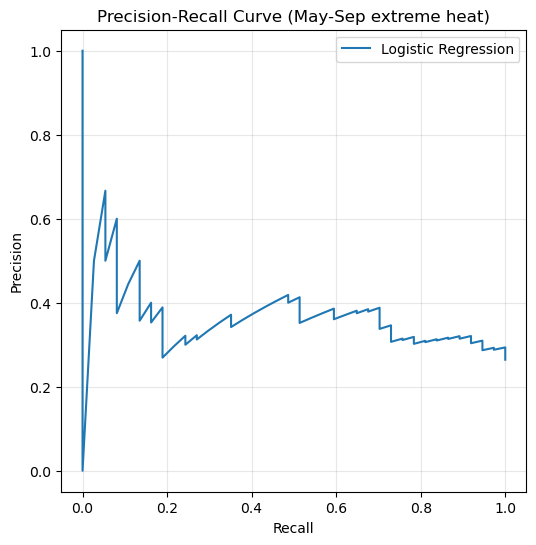

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.plot(recall, precision, label='Logistic Regression')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (May-Sep extreme heat)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Per-station TMEAN_next metrics (using Random Forest predictions):
       STATION  rmse_tmean  r2_tmean  samples
1  USW00012839    1.683668  0.884653       47
4  USW00093134    2.197362  0.886265       47
3  USW00024233    2.430709  0.938695       47
5  USW00094789    3.171373  0.951329       47
2  USW00023183    3.538178  0.946493       47
0  USW00003017    3.686070  0.950138       47
6  USW00094846    3.819893  0.950534       47


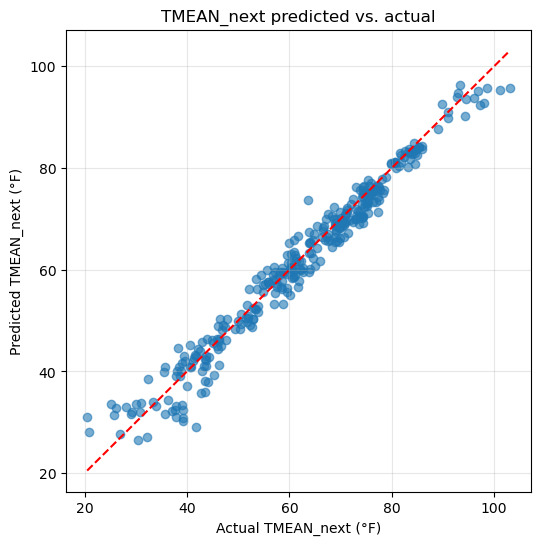

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

best_reg_name = 'Random Forest Regressor'
reg_pred_df = pd.DataFrame(reg_predictions[best_reg_name], columns=reg_targets)

test_targets_df = y_reg_test.reset_index(drop=True)
test_meta = model_df.loc[test_mask, ['STATION']].reset_index(drop=True)

station_metrics = []
for station, grp in test_meta.groupby('STATION'):
    idx = grp.index
    y_true = test_targets_df.loc[idx, 'TMEAN_next']
    y_pred = reg_pred_df.loc[idx, 'TMEAN_next']
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    station_metrics.append({'STATION': station, 'rmse_tmean': rmse, 'r2_tmean': r2, 'samples': len(idx)})

station_metrics_df = pd.DataFrame(station_metrics).sort_values('rmse_tmean')
print('Per-station TMEAN_next metrics (using Random Forest predictions):')
print(station_metrics_df)

plt.figure(figsize=(6, 6))
plt.scatter(test_targets_df['TMEAN_next'], reg_pred_df['TMEAN_next'], alpha=0.6)
lims = [min(test_targets_df['TMEAN_next'].min(), reg_pred_df['TMEAN_next'].min()),
        max(test_targets_df['TMEAN_next'].max(), reg_pred_df['TMEAN_next'].max())]
plt.plot(lims, lims, color='red', linestyle='--')
plt.xlabel('Actual TMEAN_next (°F)')
plt.ylabel('Predicted TMEAN_next (°F)')
plt.title('TMEAN_next predicted vs. actual')
plt.grid(True, alpha=0.3)
plt.show()


### PRCP_next predicted vs. actual

Scatter plot uses a log1p transform to visualize rainfall predictions that span orders of magnitude.

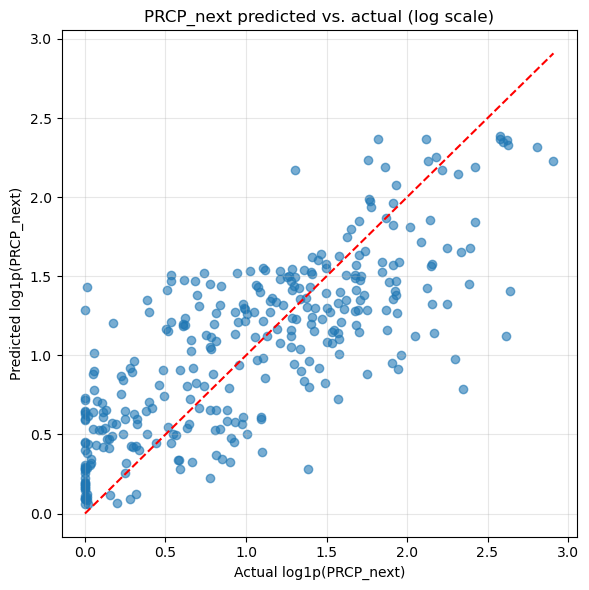

In [22]:
fig, ax = plt.subplots(figsize=(6, 6))
actual_prcp = np.log1p(test_targets_df['PRCP_next'])
pred_prcp = np.log1p(reg_pred_df['PRCP_next'])
ax.scatter(actual_prcp, pred_prcp, alpha=0.6)
lims = [min(actual_prcp.min(), pred_prcp.min()), max(actual_prcp.max(), pred_prcp.max())]
ax.plot(lims, lims, color='red', linestyle='--')
ax.set_xlabel('Actual log1p(PRCP_next)')
ax.set_ylabel('Predicted log1p(PRCP_next)')
ax.set_title('PRCP_next predicted vs. actual (log scale)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Residual diagnostics

Histogram and timeline of Random Forest residuals check for bias or temporal clustering in the test set.

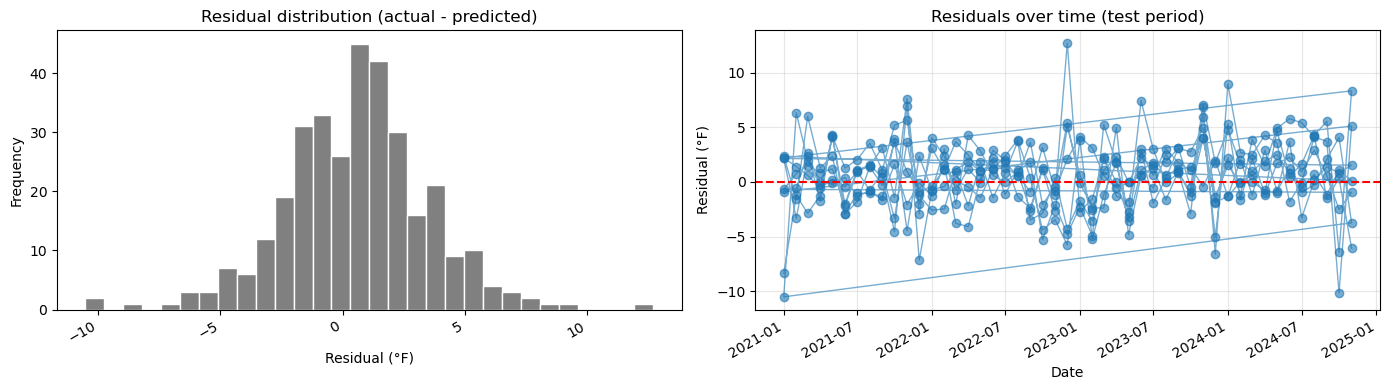

In [23]:
residuals = test_targets_df['TMEAN_next'] - reg_pred_df['TMEAN_next']
test_dates = model_df.loc[test_mask, 'ym'].reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(residuals, bins=30, color='gray', edgecolor='white')
axes[0].set_title('Residual distribution (actual - predicted)')
axes[0].set_xlabel('Residual (°F)')
axes[0].set_ylabel('Frequency')
axes[1].plot(test_dates, residuals, marker='o', linewidth=1, alpha=0.6)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals over time (test period)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Residual (°F)')
axes[1].grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### PRCP residual diagnostics

Log-transformed residuals reveal whether rainfall errors are systematic or mostly due to a few extreme events.

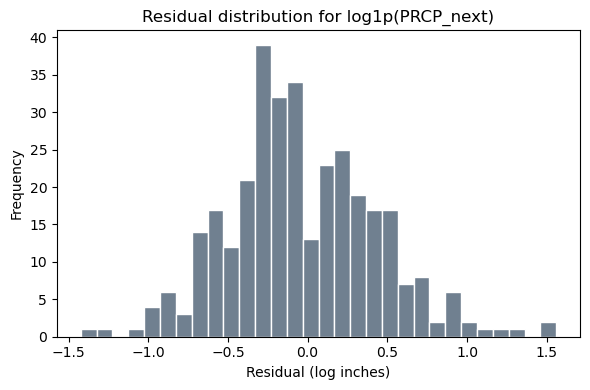

In [62]:
prcp_residuals = np.log1p(test_targets_df['PRCP_next']) - np.log1p(reg_pred_df['PRCP_next'])
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(prcp_residuals, bins=30, color='slategray', edgecolor='white')
ax.set_title('Residual distribution for log1p(PRCP_next)')
ax.set_xlabel('Residual (log inches)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### Test-period average temperature forecast

Comparing the mean actual vs. predicted `TMEAN_next` across the test months shows how closely the model tracks broad seasonal swings.

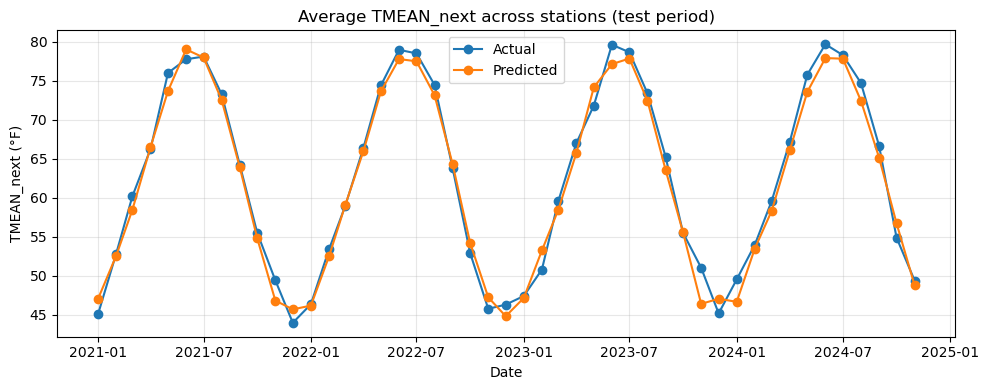

In [24]:
temporal_df = pd.DataFrame({
    'ym': test_dates,
    'actual': test_targets_df['TMEAN_next'],
    'predicted': reg_pred_df['TMEAN_next']
})
monthly_mean = temporal_df.groupby('ym').mean()
plt.figure(figsize=(10, 4))
plt.plot(monthly_mean.index, monthly_mean['actual'], label='Actual', marker='o')
plt.plot(monthly_mean.index, monthly_mean['predicted'], label='Predicted', marker='o')
plt.title('Average TMEAN_next across stations (test period)')
plt.xlabel('Date')
plt.ylabel('TMEAN_next (°F)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

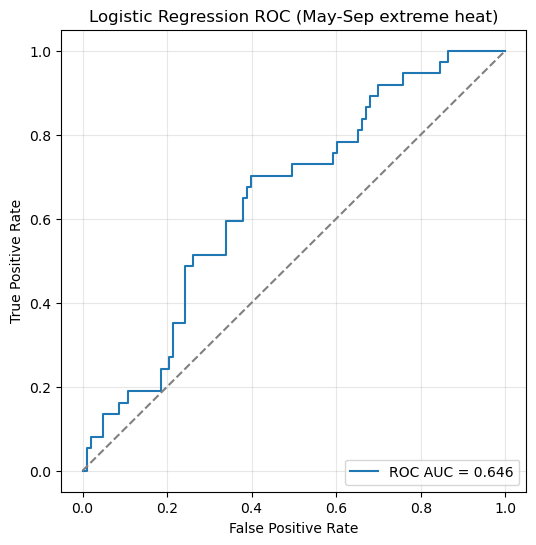

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_clf_test, y_clf_prob)
roc_auc = roc_auc_score(y_clf_test, y_clf_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC (May-Sep extreme heat)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### Monthly precipitation totals (test period)

Summed precipitation across stations per month shows whether the model captures seasonal wet/dry swings.

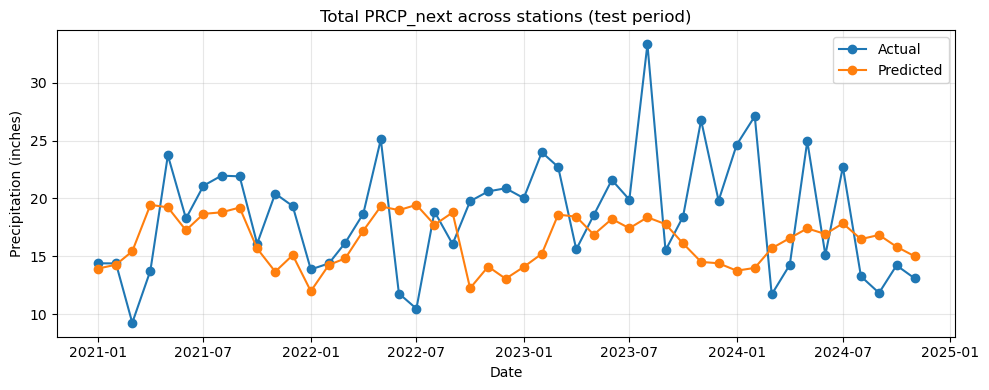

In [26]:
prcp_temporal = pd.DataFrame({
    'ym': test_dates,
    'actual': test_targets_df['PRCP_next'],
    'predicted': reg_pred_df['PRCP_next']
})
monthly_prcp = prcp_temporal.groupby('ym').sum()
plt.figure(figsize=(10, 4))
plt.plot(monthly_prcp.index, monthly_prcp['actual'], label='Actual', marker='o')
plt.plot(monthly_prcp.index, monthly_prcp['predicted'], label='Predicted', marker='o')
plt.title('Total PRCP_next across stations (test period)')
plt.xlabel('Date')
plt.ylabel('Precipitation (inches)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

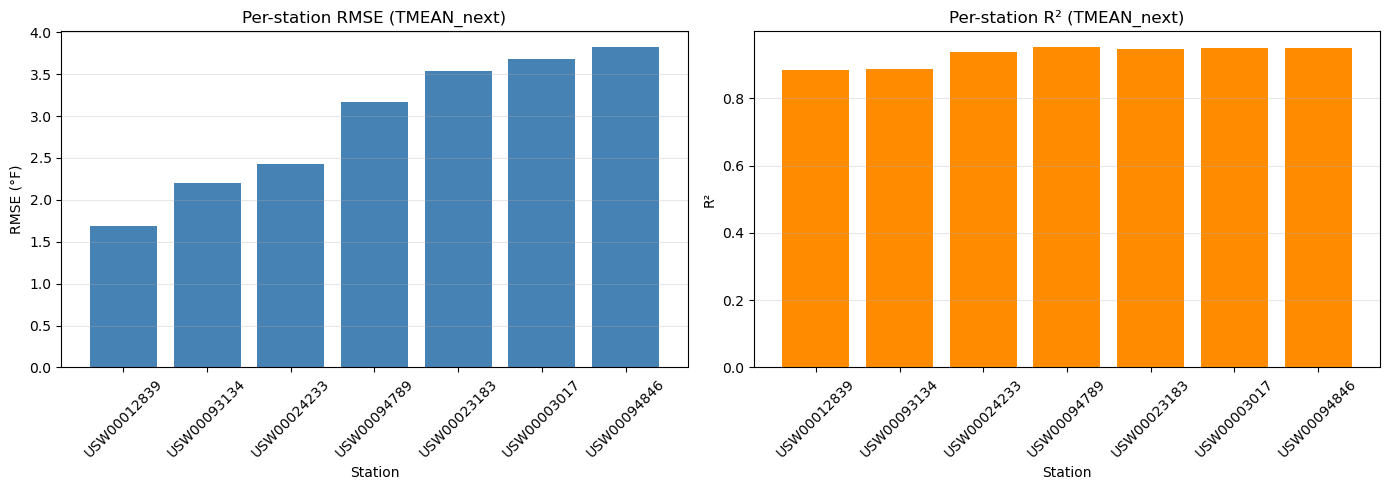

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

station_metrics_df.sort_values('rmse_tmean', inplace=True)

# RMSE
axes[0].bar(station_metrics_df['STATION'], station_metrics_df['rmse_tmean'], color='steelblue')
axes[0].set_title('Per-station RMSE (TMEAN_next)')
axes[0].set_xlabel('Station')
axes[0].set_ylabel('RMSE (°F)')
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)  

# R*2
axes[1].bar(station_metrics_df['STATION'], station_metrics_df['r2_tmean'], color='darkorange')
axes[1].set_title('Per-station R² (TMEAN_next)')
axes[1].set_xlabel('Station')
axes[1].set_ylabel('R²')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()
